In [ ]:
!wget -r -N -c -np https://physionet.org/files/challenge-2019/1.0.0/training/

--2026-09-27 14:57:24--  https://physionet.org/files/challenge-2019/1.0.0/training/
Resolving physionet.org (physionet.org)... 18.25.8.254
Connecting to physionet.org (physionet.org)|18.25.8.254|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/challenge-2019/1.0.0/training/index.html’

physionet.org/files     [ <=>                ]     491  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-09-27 14:57:25 (141 MB/s) - ‘physionet.org/files/challenge-2019/1.0.0/training/index.html’ saved [491]

Loading robots.txt; please ignore errors.
--2026-09-27 14:57:25--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK

    The file is already fully retrieved; nothing to do.

--2026-09-27 14:57:25--  https://physionet.org/files/challenge-2019/1.0.0/training/training_setA/
Reusing existing connection to ph

In [4]:
!aws s3 sync --no-sign-request \
  s3://physionet-open/challenge-2019/1.0.0/training/ \
  /content/physionet2019/

/bin/bash: line 1: aws: command not found


In [5]:
!pip -q install awscli

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 38.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


In [6]:
!aws s3 sync --no-sign-request \
  s3://physionet-open/challenge-2019/1.0.0/training/ \
  /content/physionet2019/

Streaming output truncated to the last 5000 lines.
download: s3://physionet-open/challenge-2019/1.0.0/training/training_setB/p115007.psv to physionet2019/training_setB/p115007.psv
download: s3://physionet-open/challenge-2019/1.0.0/training/training_setB/p114996.psv to physionet2019/training_setB/p114996.psv
download: s3://physionet-open/challenge-2019/1.0.0/training/training_setB/p115009.psv to physionet2019/training_setB/p115009.psv
download: s3://physionet-open/challenge-2019/1.0.0/training/training_setB/p115003.psv to physionet2019/training_setB/p115003.psv
download: s3://physionet-open/challenge-2019/1.0.0/training/training_setB/p115000.psv to physionet2019/training_setB/p115000.psv
download: s3://physionet-open/challenge-2019/1.0.0/training/training_setB/p115002.psv to physionet2019/training_setB/p115002.psv
download: s3://physionet-open/challenge-2019/1.0.0/training/training_setB/p115004.psv to physionet2019/training_setB/p115004.psv
download: s3://physionet-open/challenge-2019/1

In [7]:
import glob
import os

files = glob.glob("/content/physionet2019/**/*.psv", recursive=True)

print("Total patient files:", len(files))
print("\nFirst 10 files:")

for f in files[:10]:
    print(f)

Total patient files: 40336

First 10 files:
/content/physionet2019/training_setA/p002261.psv
/content/physionet2019/training_setA/p013090.psv
/content/physionet2019/training_setA/p014961.psv
/content/physionet2019/training_setA/p000909.psv
/content/physionet2019/training_setA/p012518.psv
/content/physionet2019/training_setA/p007028.psv
/content/physionet2019/training_setA/p017926.psv
/content/physionet2019/training_setA/p010313.psv
/content/physionet2019/training_setA/p006938.psv
/content/physionet2019/training_setA/p018794.psv


In [8]:
!find /content/physionet2019 -maxdepth 2 -type d

/content/physionet2019
/content/physionet2019/training_setA
/content/physionet2019/training_setB


In [9]:
!find /content/physionet2019 -maxdepth 2 -type f | head -20

/content/physionet2019/training_setA/p015005.psv
/content/physionet2019/training_setA/p015008.psv
/content/physionet2019/training_setA/p000001.psv
/content/physionet2019/training_setA/p000005.psv
/content/physionet2019/training_setA/p000004.psv
/content/physionet2019/training_setA/p000007.psv
/content/physionet2019/training_setA/p000003.psv
/content/physionet2019/training_setA/p000011.psv
/content/physionet2019/training_setA/p000008.psv
/content/physionet2019/training_setA/p000010.psv
/content/physionet2019/training_setA/p000006.psv
/content/physionet2019/training_setA/p000012.psv
/content/physionet2019/training_setA/p000002.psv
/content/physionet2019/training_setA/p000013.psv
/content/physionet2019/training_setA/p000009.psv
/content/physionet2019/training_setA/p000014.psv
/content/physionet2019/training_setA/p000015.psv
/content/physionet2019/training_setA/p000017.psv
/content/physionet2019/training_setA/p000016.psv
/content/physionet2019/training_setA/p000022.psv


In [10]:
patient_file = files[0]

print("Selected patient:")
print(patient_file)

Selected patient:
/content/physionet2019/training_setA/p002261.psv


In [11]:
import pandas as pd

df = pd.read_csv(patient_file, sep="|")

print("Shape:", df.shape)

df.head()

Shape: (49, 41)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,84.5,100.0,35.75,164.0,113.0,92.0,18.0,NaN,1.0,25.0,...,5.2,193.0,91.0,43.84,1,NaN,NaN,-5.85,6,0
1,87.0,100.0,36.20,146.0,110.0,89.0,18.0,NaN,NaN,NaN,...,NaN,NaN,NaN,43.84,1,NaN,NaN,-5.85,7,0
2,87.0,100.0,36.50,145.0,108.0,89.0,18.0,NaN,NaN,NaN,...,NaN,NaN,NaN,43.84,1,NaN,NaN,-5.85,8,0
3,85.0,99.0,36.75,147.5,109.0,87.5,18.0,NaN,NaN,NaN,...,NaN,NaN,NaN,43.84,1,NaN,NaN,-5.85,9,0
4,78.0,99.0,37.10,151.0,111.0,89.0,18.0,NaN,3.0,NaN,...,NaN,NaN,127.0,43.84,1,NaN,NaN,-5.85,10,0


In [12]:
print(df.columns.tolist())

['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 41 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HR                48 non-null     float64
 1   O2Sat             48 non-null     float64
 2   Temp              44 non-null     float64
 3   SBP               48 non-null     float64
 4   MAP               48 non-null     float64
 5   DBP               48 non-null     float64
 6   Resp              48 non-null     float64
 7   EtCO2             0 non-null      float64
 8   BaseExcess        6 non-null      float64
 9   HCO3              6 non-null      float64
 10  FiO2              10 non-null     float64
 11  pH                6 non-null      float64
 12  PaCO2             6 non-null      float64
 13  SaO2              2 non-null      float64
 14  AST               7 non-null      float64
 15  BUN               7 non-null      float64
 16  Alkalinephos      7 non-null      float64
 17 

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
HR,48.0,67.822917,9.370897e+00,51.00,59.7500,68.50,74.000,87.00
O2Sat,48.0,96.781250,1.918294e+00,93.00,95.0000,97.00,98.250,100.00
Temp,44.0,36.604545,2.621064e-01,35.75,36.4750,36.60,36.800,37.10
SBP,48.0,157.093750,9.349398e+00,133.00,149.8750,157.00,164.000,174.00
MAP,48.0,114.447917,6.424885e+00,102.00,110.0000,113.00,118.500,128.00
DBP,48.0,89.135417,6.333581e+00,79.00,84.7500,89.00,92.750,103.00
Resp,48.0,17.729167,2.224043e+00,12.00,17.0000,18.00,19.000,25.00
EtCO2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaseExcess,6.0,-0.166667,2.926887e+00,-5.00,-1.5000,0.50,1.750,3.00
HCO3,6.0,22.166667,2.483277e+00,20.00,20.0000,21.50,24.500,25.00


In [15]:
missing = df.isna().sum().sort_values(ascending=False)

print(missing)

EtCO2               49
Unit2               49
TroponinI           49
Unit1               49
Lactate             48
SaO2                47
Bilirubin_direct    46
Magnesium           45
Calcium             45
Phosphate           45
Fibrinogen          44
WBC                 43
PTT                 43
pH                  43
Chloride            43
PaCO2               43
BaseExcess          43
HCO3                43
Hgb                 42
Alkalinephos        42
AST                 42
BUN                 42
Bilirubin_total     42
Potassium           42
Creatinine          42
Platelets           40
Hct                 40
FiO2                39
Glucose             14
Temp                 5
HR                   1
O2Sat                1
MAP                  1
DBP                  1
Resp                 1
SBP                  1
Age                  0
Gender               0
HospAdmTime          0
ICULOS               0
SepsisLabel          0
dtype: int64


In [16]:
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

print(missing_percent)

EtCO2               100.000000
Unit2               100.000000
TroponinI           100.000000
Unit1               100.000000
Lactate              97.959184
SaO2                 95.918367
Bilirubin_direct     93.877551
Magnesium            91.836735
Calcium              91.836735
Phosphate            91.836735
Fibrinogen           89.795918
WBC                  87.755102
PTT                  87.755102
pH                   87.755102
Chloride             87.755102
PaCO2                87.755102
BaseExcess           87.755102
HCO3                 87.755102
Hgb                  85.714286
Alkalinephos         85.714286
AST                  85.714286
BUN                  85.714286
Bilirubin_total      85.714286
Potassium            85.714286
Creatinine           85.714286
Platelets            81.632653
Hct                  81.632653
FiO2                 79.591837
Glucose              28.571429
Temp                 10.204082
HR                    2.040816
O2Sat                 2.040816
MAP     

In [17]:
print(df[["ICULOS", "SepsisLabel"]].head(15))

    ICULOS  SepsisLabel
0        6            0
1        7            0
2        8            0
3        9            0
4       10            0
5       11            0
6       12            0
7       13            0
8       14            0
9       15            0
10      16            0
11      17            0
12      18            0
13      19            0
14      20            0


In [18]:
print(df[["ICULOS", "SepsisLabel"]].tail(15))

    ICULOS  SepsisLabel
34      40            0
35      41            0
36      42            0
37      43            0
38      44            0
39      45            0
40      46            0
41      47            0
42      48            0
43      49            0
44      50            0
45      51            0
46      52            0
47      53            0
48      54            0


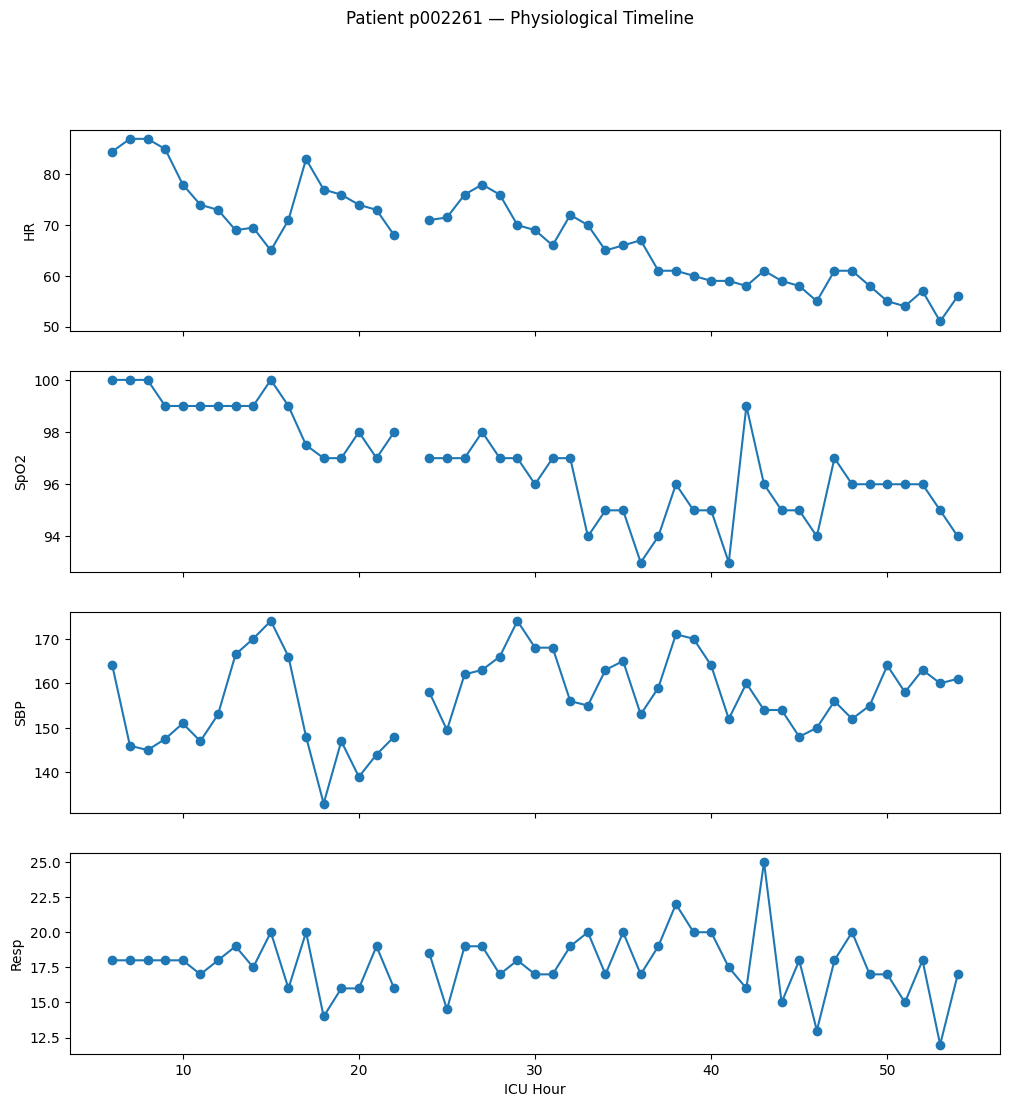

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(df["ICULOS"], df["HR"], marker="o")
axes[0].set_ylabel("HR")

axes[1].plot(df["ICULOS"], df["O2Sat"], marker="o")
axes[1].set_ylabel("SpO2")

axes[2].plot(df["ICULOS"], df["SBP"], marker="o")
axes[2].set_ylabel("SBP")

axes[3].plot(df["ICULOS"], df["Resp"], marker="o")
axes[3].set_ylabel("Resp")
axes[3].set_xlabel("ICU Hour")

plt.suptitle("Patient p002261 — Physiological Timeline")
plt.show()

In [20]:
print(df["SepsisLabel"].value_counts())

SepsisLabel
0    49
Name: count, dtype: int64


In [21]:
print("Number of positive labels:", df["SepsisLabel"].sum())
print("First positive hour:",
      df.loc[df["SepsisLabel"] == 1, "ICULOS"].min())

Number of positive labels: 0
First positive hour: nan


In [22]:
label_changes = df.loc[
    df["SepsisLabel"].ne(df["SepsisLabel"].shift())
]

print(label_changes[["ICULOS", "SepsisLabel"]])

   ICULOS  SepsisLabel
0       6            0


In [23]:
vitals = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp"]

delta_df = df[vitals].diff()

delta_df.head()

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.5,0.0,0.45,-18.0,-3.0,-3.0,0.0
2,0.0,0.0,0.30,-1.0,-2.0,0.0,0.0
3,-2.0,-1.0,0.25,2.5,1.0,-1.5,0.0
4,-7.0,0.0,0.35,3.5,2.0,1.5,0.0


In [24]:
patient_summary = []

for f in files[:20]:
    temp = pd.read_csv(f, sep="|")

    patient_id = os.path.basename(f).replace(".psv", "")

    patient_summary.append({
        "patient_id": patient_id,
        "hours": len(temp),
        "positive_labels": int(temp["SepsisLabel"].sum()),
        "has_sepsis_label": temp["SepsisLabel"].sum() > 0,
        "HR_missing_pct": temp["HR"].isna().mean() * 100,
        "O2Sat_missing_pct": temp["O2Sat"].isna().mean() * 100,
        "Temp_missing_pct": temp["Temp"].isna().mean() * 100,
        "SBP_missing_pct": temp["SBP"].isna().mean() * 100,
        "Resp_missing_pct": temp["Resp"].isna().mean() * 100
    })

patient_summary = pd.DataFrame(patient_summary)

patient_summary

,patient_id,hours,positive_labels,has_sepsis_label,HR_missing_pct,O2Sat_missing_pct,Temp_missing_pct,SBP_missing_pct,Resp_missing_pct
0,p002261,49,0,False,2.040816,2.040816,10.204082,2.040816,2.040816
1,p013090,11,10,True,9.090909,9.090909,72.727273,9.090909,9.090909
2,p014961,44,0,False,2.272727,4.545455,75.000000,2.272727,4.545455
3,p000909,25,0,False,4.000000,4.000000,8.000000,4.000000,4.000000
4,p012518,45,0,False,2.222222,26.666667,77.777778,24.444444,6.666667
5,p007028,18,0,False,0.000000,0.000000,66.666667,0.000000,0.000000
6,p017926,21,0,False,0.000000,0.000000,61.904762,0.000000,0.000000
7,p010313,17,0,False,23.529412,23.529412,64.705882,23.529412,23.529412
8,p006938,49,0,False,4.081633,4.081633,6.122449,4.081633,36.734694
9,p018794,21,0,False,0.000000,0.000000,100.000000,0.000000,0.000000


In [25]:
print(patient_summary["hours"].describe())

count    20.000000
mean     31.050000
std      14.199611
min       8.000000
25%      20.250000
50%      27.500000
75%      45.250000
max      51.000000
Name: hours, dtype: float64


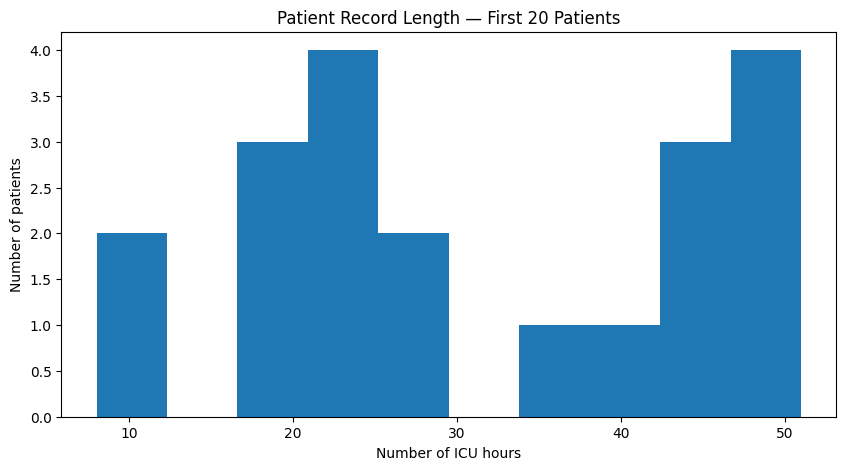

In [26]:
plt.figure(figsize=(10, 5))

plt.hist(patient_summary["hours"], bins=10)

plt.xlabel("Number of ICU hours")
plt.ylabel("Number of patients")
plt.title("Patient Record Length — First 20 Patients")

plt.show()

In [27]:
missing_summary = patient_summary[
    [
        "HR_missing_pct",
        "O2Sat_missing_pct",
        "Temp_missing_pct",
        "SBP_missing_pct",
        "Resp_missing_pct"
    ]
]

missing_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
HR_missing_pct,20.0,7.121858,8.048312,0.000000,0.000000,4.040816,11.979167,23.809524
O2Sat_missing_pct,20.0,9.553526,9.366908,0.000000,1.530612,5.844156,17.864924,26.666667
Temp_missing_pct,20.0,63.409513,29.359988,6.122449,63.553114,75.000000,79.745370,100.000000
SBP_missing_pct,20.0,17.420970,23.844618,0.000000,1.530612,9.902597,23.599440,89.130435
Resp_missing_pct,20.0,12.696952,19.575214,0.000000,0.000000,5.606061,17.129630,83.333333


In [28]:
positive_patients = []

for f in files[:100]:
    temp = pd.read_csv(f, sep="|")

    if temp["SepsisLabel"].sum() > 0:
        positive_patients.append(f)

print("Positive patients found:", len(positive_patients))

Positive patients found: 13


In [29]:
positive_file = positive_patients[0]

positive_df = pd.read_csv(positive_file, sep="|")

print("Patient:", os.path.basename(positive_file))
print("Shape:", positive_df.shape)

positive_df[["ICULOS", "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "SepsisLabel"]].tail(20)

Patient: p013090.psv
Shape: (11, 41)


,ICULOS,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,SepsisLabel
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2,74.0,100.0,NaN,123.0,80.0,66.0,18.0,1
2,3,75.0,100.0,NaN,122.0,82.0,67.0,16.0,1
3,4,75.0,100.0,NaN,122.0,82.0,67.0,16.0,1
4,5,73.0,100.0,36.83,125.0,85.0,69.0,17.5,1
5,6,74.0,99.0,NaN,114.0,74.0,58.0,16.0,1
6,7,74.0,99.0,36.89,112.0,75.0,61.0,18.0,1
7,8,76.0,98.0,NaN,110.0,72.0,58.0,16.0,1
8,9,73.0,98.0,37.00,122.0,79.0,64.0,16.0,1
9,10,91.0,98.0,NaN,119.0,81.0,63.0,15.0,1


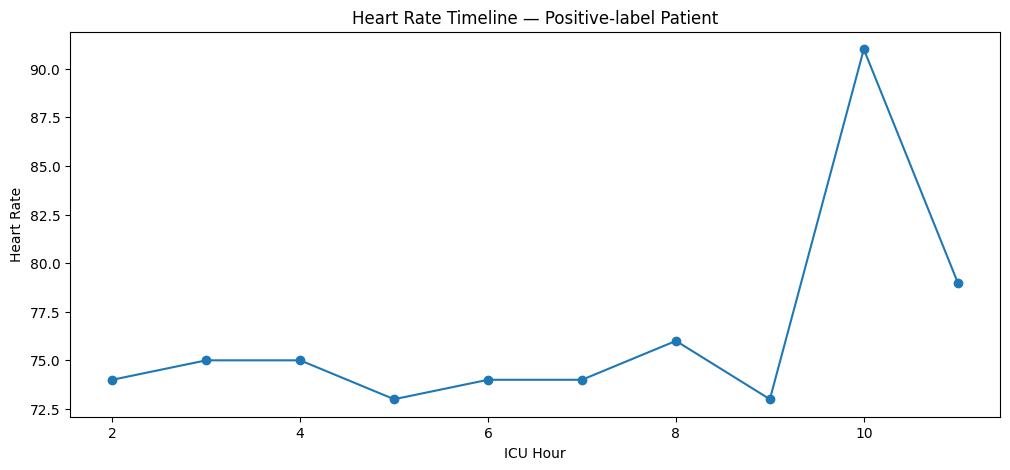

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    positive_df["ICULOS"],
    positive_df["HR"],
    marker="o",
    label="HR"
)

plt.xlabel("ICU Hour")
plt.ylabel("Heart Rate")
plt.title("Heart Rate Timeline — Positive-label Patient")

plt.show()

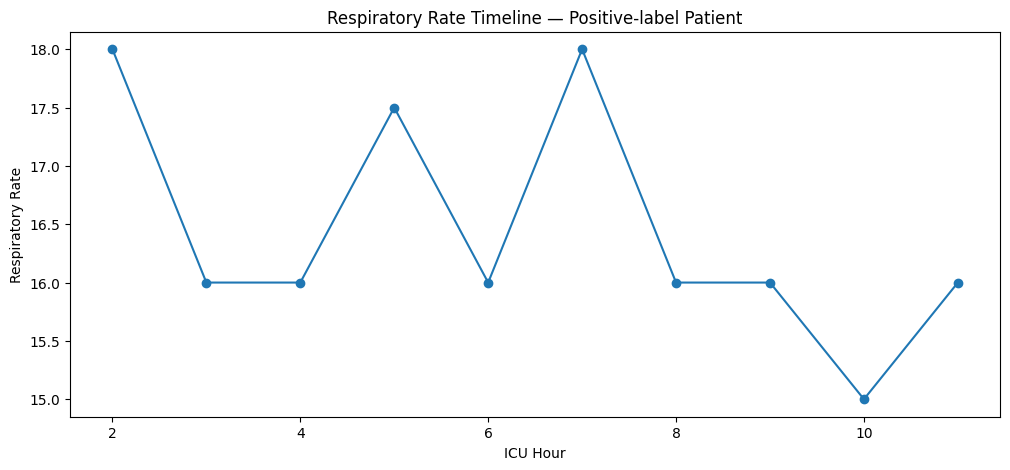

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(
    positive_df["ICULOS"],
    positive_df["Resp"],
    marker="o"
)

plt.xlabel("ICU Hour")
plt.ylabel("Respiratory Rate")
plt.title("Respiratory Rate Timeline — Positive-label Patient")

plt.show()

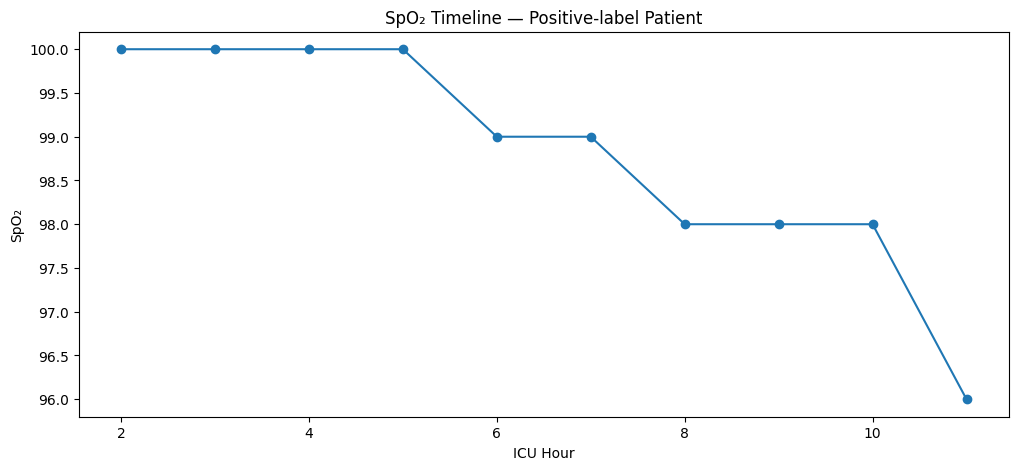

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    positive_df["ICULOS"],
    positive_df["O2Sat"],
    marker="o"
)


plt.xlabel("ICU Hour")
plt.ylabel("SpO₂")
plt.title("SpO₂ Timeline — Positive-label Patient")

plt.show()